# Title : Glucose Level Prediction Using Machine Learning

This project aims to predict glucose levels using health-related attributes from the Framingham Heart Study dataset. Machine learning techniques were applied to analyze the relationship between various medical factors and glucose levels.

In [ ]:
#importing required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


In [ ]:
#load dataset
df=pd.read_csv('framingham.csv')
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [ ]:
#EDA
df.describe().T

,count,mean,std,min,25%,50%,75%,max
male,4240.0,0.429245,0.495027,0.00,0.00,0.0,1.00,1.0
age,4240.0,49.580189,8.572942,32.00,42.00,49.0,56.00,70.0
education,4135.0,1.979444,1.019791,1.00,1.00,2.0,3.00,4.0
currentSmoker,4240.0,0.494104,0.500024,0.00,0.00,0.0,1.00,1.0
cigsPerDay,4211.0,9.005937,11.922462,0.00,0.00,0.0,20.00,70.0
BPMeds,4187.0,0.029615,0.169544,0.00,0.00,0.0,0.00,1.0
prevalentStroke,4240.0,0.005896,0.076569,0.00,0.00,0.0,0.00,1.0
prevalentHyp,4240.0,0.310613,0.462799,0.00,0.00,0.0,1.00,1.0
diabetes,4240.0,0.025708,0.158280,0.00,0.00,0.0,0.00,1.0
totChol,4190.0,236.699523,44.591284,107.00,206.00,234.0,263.00,696.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 530.1 KB


In [ ]:
df.isnull().sum()

,0
male,0
age,0
education,105
currentSmoker,0
cigsPerDay,29
BPMeds,53
prevalentStroke,0
prevalentHyp,0
diabetes,0
totChol,50


In [ ]:
#Handling missing values
df=df.dropna(subset=['glucose'])
df['education']=df['education'].fillna(df['education'].mode()[0])
df['cigsPerDay']=df['cigsPerDay'].fillna(df['cigsPerDay'].mode()[0])
df['BPMeds']=df['BPMeds'].fillna(df['BPMeds'].mode()[0])
df['BMI']=df['BMI'].fillna(df['BMI'].mode()[0])
df['totChol']=df['totChol'].fillna(df['totChol'].mean())
df['heartRate']=df['heartRate'].fillna(df['heartRate'].mean())


In [ ]:
#feature selection
X=df.drop(columns='glucose')
y=df['glucose']

In [ ]:
#feature scaling
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

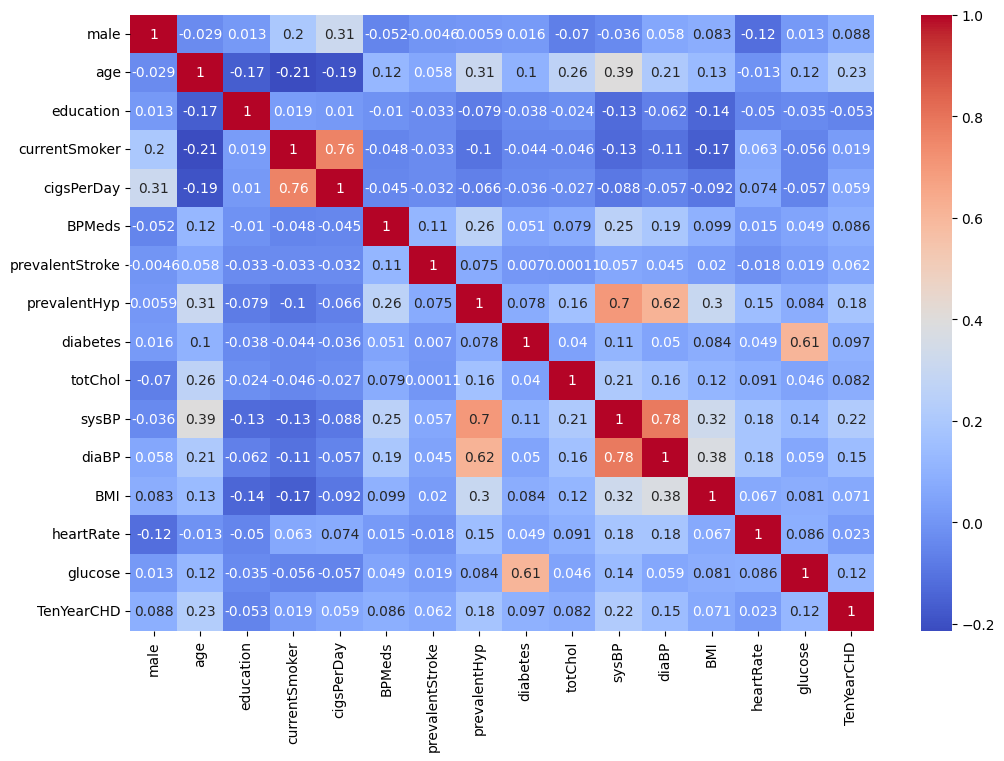

In [ ]:
corr = df.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [ ]:
print(X_scaled.shape)
print(y.shape)

(4240, 15)
(4240,)


In [ ]:
#train and test model
X_train,X_test,y_train,y_test=train_test_split(X_scaled,y,test_size=0.2,random_state=42)

In [ ]:
# Linear Regression
model=LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [ ]:
y_pred=model.predict(X_test)

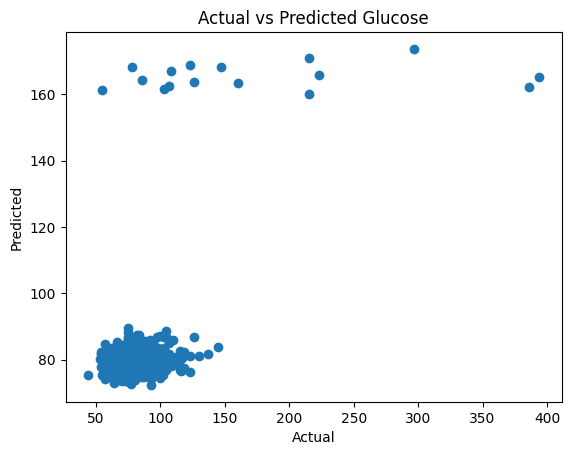

In [ ]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Glucose")
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score,accuracy_score

In [ ]:
print("MSE LR= ",mean_squared_error(y_test,y_pred))
print("MAE LR= ",mean_absolute_error(y_test,y_pred))
print("RMSE LR= ",np.sqrt(mean_squared_error(y_test,y_pred)))
print('R2 Score LR = ',r2_score(y_test,y_pred))

MSE LR=  342.8314923284609
MAE LR=  10.583874884586363
RMSE LR=  18.515709339057494
R2 Score LR =  0.3461329292690336


In [ ]:
from sklearn.tree import DecisionTreeRegressor
dtr=DecisionTreeRegressor()
dtr.fit(X_train,y_train)

DecisionTreeRegressor()

In [ ]:
dtr_pred=dtr.predict(X_test)

In [ ]:
print("MSE DTR= ",mean_squared_error(y_test,dtr_pred))
print("MAE DTR= ",mean_absolute_error(y_test,dtr_pred))
print("RMSE DTR= ",np.sqrt(mean_squared_error(y_test,dtr_pred)))
print('R2 Score DTR = ',r2_score(y_test,dtr_pred))

MSE DTR=  786.4150943396227
MAE DTR=  16.370283018867923
RMSE DTR=  28.043093522998184
R2 Score DTR =  -0.4998941043076903


In [ ]:
from sklearn.ensemble import RandomForestRegressor
rf=RandomForestRegressor(n_estimators=200,random_state=42)
rf.fit(X_train,y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [ ]:
rf_pred=rf.predict(X_test)

In [ ]:
importance=pd.DataFrame({'Features' : X.columns,'Importance':rf.feature_importances_})
importance

,Features,Importance
0,male,0.007577
1,age,0.068588
2,education,0.026296
3,currentSmoker,0.004298
4,cigsPerDay,0.034088
5,BPMeds,0.005307
6,prevalentStroke,0.001317
7,prevalentHyp,0.004867
8,diabetes,0.374370
9,totChol,0.079475


<Axes: xlabel='Importance', ylabel='Features'>

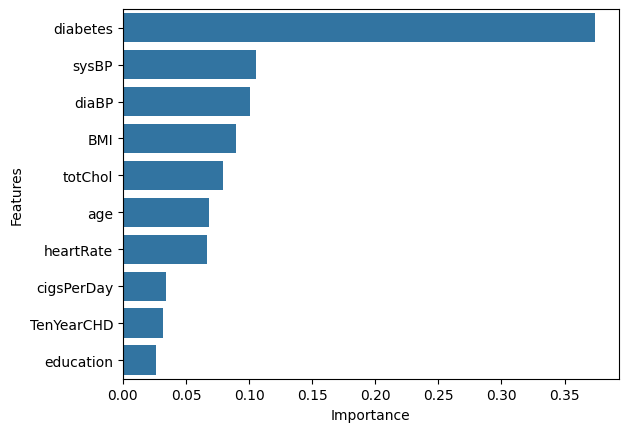

In [ ]:
sns.barplot(
    x='Importance',
    y='Features',
    data=importance.sort_values(
        by='Importance',
        ascending=False
    ).head(10)
)

In [ ]:
print("MSE_RF = ",mean_squared_error(y_test,rf_pred))
print("MAE_RF = ",mean_absolute_error(y_test,rf_pred))
print("RMSE_RF = ",np.sqrt(mean_squared_error(y_test,rf_pred)))
print('R2 Score RF= ',r2_score(y_test,rf_pred))

MSE_RF =  380.1661858490566
MAE_RF =  11.09134433962264
RMSE_RF =  19.49785080076921
R2 Score RF=  0.27492614915922475


In [ ]:
from xgboost import XGBRegressor
xgb=XGBRegressor(n_estimators=200,n_jobs=-1)
xgb.fit(X_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=-1, num_parallel_tree=None, ...)

In [ ]:
xgb_pred=xgb.predict(X_test)

In [ ]:
print("MSE_XGB = ",mean_squared_error(y_test,xgb_pred))
print("MAE_XGB = ",mean_absolute_error(y_test,xgb_pred))
print("RMSE_XGB = ",np.sqrt(mean_squared_error(y_test,xgb_pred)))
print('R2 Score XGB = ',r2_score(y_test,xgb_pred))


MSE_XGB =  494.3042757534464
MAE_XGB =  12.347744473871195
RMSE_XGB =  22.232954723865348
R2 Score XGB =  0.057235708885703396


In [ ]:
Result=pd.DataFrame({'Models':['Linear Regression','Random Forest Regressor','XGB Regressor','Decision Tree Regressor'],
              'MSE':[mean_squared_error(y_test,y_pred),mean_squared_error(y_test,rf_pred),mean_squared_error(y_test,xgb_pred),mean_squared_error(y_test,dtr_pred)],
              'MAE':[mean_absolute_error(y_test,y_pred),mean_absolute_error(y_test,rf_pred),mean_absolute_error(y_test,xgb_pred),mean_absolute_error(y_test,dtr_pred)],
              'RMSE':[np.sqrt(mean_squared_error(y_test,y_pred)),np.sqrt(mean_squared_error(y_test,rf_pred)),np.sqrt(mean_squared_error(y_test,xgb_pred)),np.sqrt(mean_squared_error(y_test,dtr_pred))],
              'R2 Score':[r2_score(y_test,y_pred),r2_score(y_test,rf_pred),r2_score(y_test,xgb_pred),r2_score(y_test,dtr_pred)]})
print('Result : \n',Result)

Result : 
                     Models         MSE        MAE       RMSE  R2 Score
0        Linear Regression  342.831492  10.583875  18.515709  0.346133
1  Random Forest Regressor  380.166186  11.091344  19.497851  0.274926
2            XGB Regressor  494.304276  12.347744  22.232955  0.057236
3  Decision Tree Regressor  786.415094  16.370283  28.043094 -0.499894


###Conclusion :
The study successfully implemented machine learning models for glucose prediction. Among all tested algorithms, Linear Regression provided the most reliable results on the given dataset. The project demonstrates the application of data preprocessing, exploratory data analysis, machine learning, and performance evaluation in healthcare analytics.